### 01 Explorative Analysis of German Weather Data
Leonie Schafferhans <br>
`env ch1` <br>

In [1]:
import pandas as pd
from wetterdienst.provider.dwd.observation import DwdObservationRequest
import matplotlib.pyplot as plt
import numpy as np

In [2]:
request = DwdObservationRequest(
    parameters=[("hourly", "temperature_air")],  #parameters=[("hourly", "temperature_air")], 
    periods= ["historical", "recent"],
).filter_by_station_id(station_id=(3987,))  # Potsdam

stations_df = request.df
print(stations_df.head())

shape: (1, 10)
┌────────────┬────────────┬────────────┬────────────┬───┬───────────┬────────┬─────────┬───────────┐
│ resolution ┆ dataset    ┆ station_id ┆ start_date ┆ … ┆ longitude ┆ height ┆ name    ┆ state     │
│ ---        ┆ ---        ┆ ---        ┆ ---        ┆   ┆ ---       ┆ ---    ┆ ---     ┆ ---       │
│ str        ┆ str        ┆ str        ┆ datetime[μ ┆   ┆ f64       ┆ f64    ┆ str     ┆ str       │
│            ┆            ┆            ┆ s, UTC]    ┆   ┆           ┆        ┆         ┆           │
╞════════════╪════════════╪════════════╪════════════╪═══╪═══════════╪════════╪═════════╪═══════════╡
│ hourly     ┆ temperatur ┆ 03987      ┆ 1893-01-01 ┆ … ┆ 13.0622   ┆ 81.0   ┆ Potsdam ┆ Brandenbu │
│            ┆ e_air      ┆            ┆ 00:00:00   ┆   ┆           ┆        ┆         ┆ rg        │
│            ┆            ┆            ┆ UTC        ┆   ┆           ┆        ┆         ┆           │
└────────────┴────────────┴────────────┴────────────┴───┴───────────┴───────

In [3]:
values = request.values.all().df
values.head()
values.to_pandas().to_csv("DWD_Precipitation_Station3987_1978-2025.csv")

In [46]:
df = pd.read_csv("DWD_Precipitation_Station3987_1978-2025.csv")

In [52]:
print(df.isnull().sum())
print(df.isna().sum())
print(df.notnull().sum())

Unnamed: 0    0
station_id    0
resolution    0
dataset       0
parameter     0
date          0
value         0
quality       0
dtype: int64
Unnamed: 0    0
station_id    0
resolution    0
dataset       0
parameter     0
date          0
value         0
quality       0
dtype: int64
Unnamed: 0    2329111
station_id    2329111
resolution    2329111
dataset       2329111
parameter     2329111
date          2329111
value         2329111
quality       2329111
dtype: int64


In [5]:
df = df[df['parameter'] == "temperature_air_mean_2m"]
print(df.head(15))

         Unnamed: 0  station_id resolution          dataset  \
1164508     1164508        3987     hourly  temperature_air   
1164509     1164509        3987     hourly  temperature_air   
1164510     1164510        3987     hourly  temperature_air   
1164511     1164511        3987     hourly  temperature_air   
1164512     1164512        3987     hourly  temperature_air   
1164513     1164513        3987     hourly  temperature_air   
1164514     1164514        3987     hourly  temperature_air   
1164515     1164515        3987     hourly  temperature_air   
1164516     1164516        3987     hourly  temperature_air   
1164517     1164517        3987     hourly  temperature_air   
1164518     1164518        3987     hourly  temperature_air   
1164519     1164519        3987     hourly  temperature_air   
1164520     1164520        3987     hourly  temperature_air   
1164521     1164521        3987     hourly  temperature_air   
1164522     1164522        3987     hourly  temperature

In [6]:
# Keep only relevant columns and rename for clarity
df = df[['date', 'value', 'quality']]
df = df[['date', 'value']]
df = df.rename(columns={'value': 'temperature'})

In [43]:
print(df[df['temperature'] > 30].count())

temperature       4830
temp_roll_7d      4830
temp_roll_30d     4830
temp_roll_365d    4802
year              4830
month             4830
decade            4830
temp_roll_180d    4828
dtype: int64


In [7]:
# Convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
print(df.head())

                           temperature
date                                  
1893-01-01 01:00:00+00:00        -12.3
1893-01-01 02:00:00+00:00        -10.9
1893-01-01 03:00:00+00:00         -9.9
1893-01-01 04:00:00+00:00         -9.4
1893-01-01 05:00:00+00:00         -8.9


In [8]:
print("Basic Info:")
print(df.info())
print("\nDescriptive Statistics:")
print(df['temperature'].describe())

Basic Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1164603 entries, 1893-01-01 01:00:00+00:00 to 2025-11-11 23:00:00+00:00
Data columns (total 1 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   temperature  1164603 non-null  float64
dtypes: float64(1)
memory usage: 17.8 MB
None

Descriptive Statistics:
count    1.164603e+06
mean     8.955235e+00
std      8.368034e+00
min     -2.680000e+01
25%      2.700000e+00
50%      8.800000e+00
75%      1.500000e+01
max      3.860000e+01
Name: temperature, dtype: float64


In [ ]:
# resample daily, monthly and yearly dataframes
df_daily = df['temperature'].resample('D').mean()
df_monthly = df['temperature'].resample('M').mean()
df_yearly = df['temperature'].resample('Y').mean()

In [22]:
print(df_daily.head())
print(df_monthly.head())
print(df_yearly.head())

date
1893-01-01 00:00:00+00:00   -10.352174
1893-01-02 00:00:00+00:00   -12.454167
1893-01-03 00:00:00+00:00   -13.554167
1893-01-04 00:00:00+00:00    -6.429167
1893-01-05 00:00:00+00:00    -5.404167
Freq: D, Name: temperature, dtype: float64
date
1893-01-31 00:00:00+00:00    -8.586676
1893-02-28 00:00:00+00:00     1.744643
1893-03-31 00:00:00+00:00     4.368011
1893-04-30 00:00:00+00:00     8.427500
1893-05-31 00:00:00+00:00    12.552688
Freq: ME, Name: temperature, dtype: float64
date
1893-12-31 00:00:00+00:00    8.038600
1894-12-31 00:00:00+00:00    8.429315
1895-12-31 00:00:00+00:00    7.873642
1896-12-31 00:00:00+00:00    8.070640
1897-12-31 00:00:00+00:00    8.091792
Freq: YE-DEC, Name: temperature, dtype: float64


In [26]:
df['temp_roll_7d'] = df['temperature'].rolling(7*24).mean()      # 7-day rolling mean
df['temp_roll_30d'] = df['temperature'].rolling(30*24).mean()  # 30-day rolling mean
df['temp_roll_180d']   = df['temperature'].rolling(180*24).mean()  # 180-day rolling mean
df['temp_roll_365d'] = df['temperature'].rolling(365*24).mean()  # 365-day rolling mean


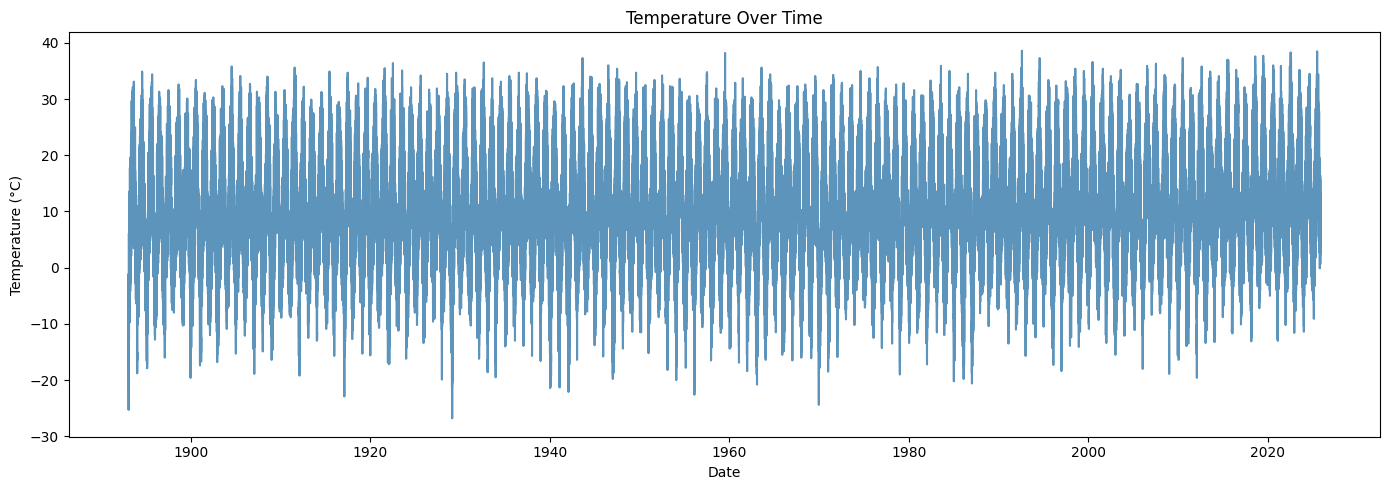

In [35]:
plt.figure(figsize=(14,5))
plt.plot(df['temperature'], color="#5c94bc", label='Hourly Temperature')
plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

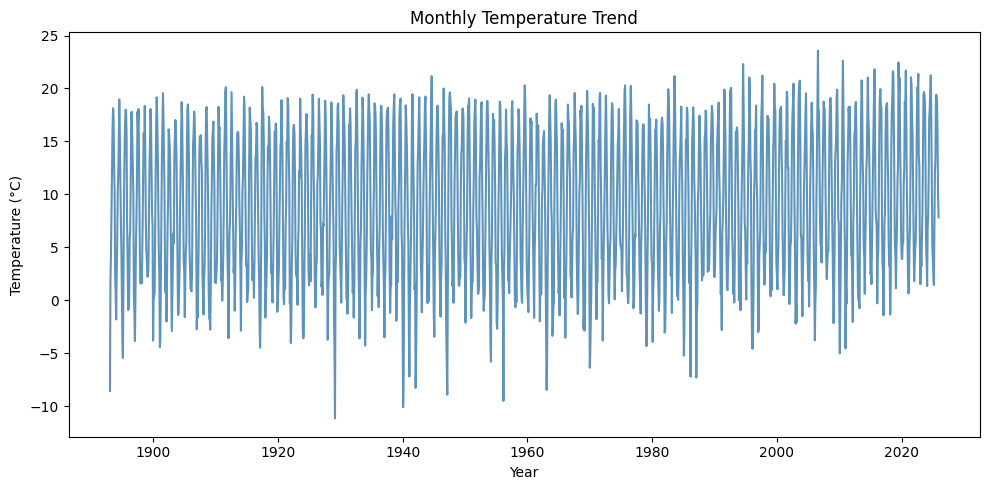

In [54]:
plt.figure(figsize=(10,5))
plt.plot(df_monthly,color="#5c94bc", label='Monthly Temperature')
plt.title("Monthly Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

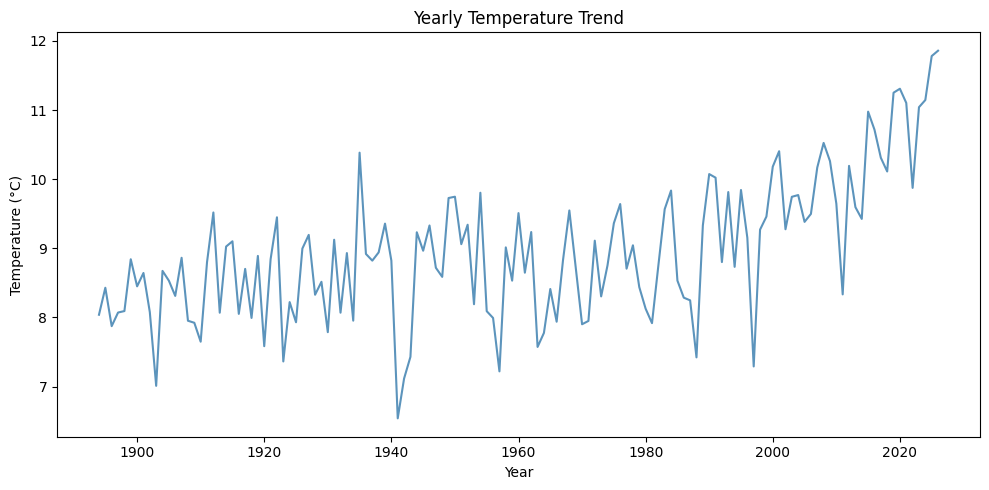

In [12]:
plt.figure(figsize=(10,5))
plt.plot(df_yearly,color="#5c94bc", label='Yearly Temperature')
plt.title("Yearly Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

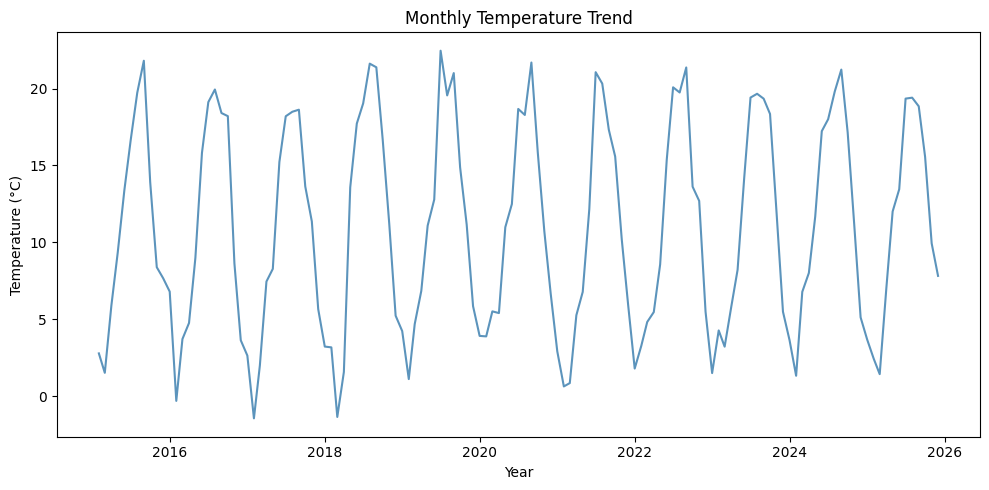

In [25]:
mask = (df.index >= "2015-01-01") & (df.index <= "2025-12-31")
df_filtered_m = df.loc[mask]
plt.figure(figsize=(10,5))
plt.plot(df_filtered_m['temperature'].resample('ME').mean(),color="#5c94bc", label='Monthly Temperature')
plt.title("Monthly Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

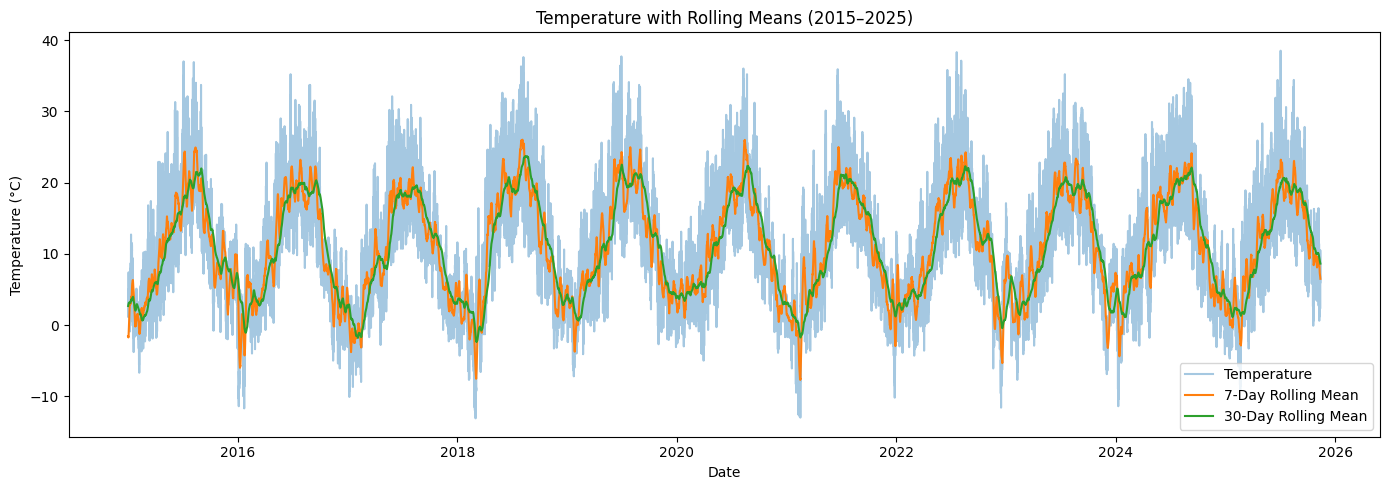

In [20]:
mask = (df.index >= "2015-01-01") & (df.index <= "2025-12-31")
df_filtered = df.loc[mask]

plt.figure(figsize=(14,5))
plt.plot(df_filtered['temperature'], alpha=0.4, label='Temperature')
plt.plot(df_filtered['temp_roll_7d'], label='7-Day Rolling Mean')
plt.plot(df_filtered['temp_roll_30d'], label='30-Day Rolling Mean')


plt.title("Temperature with Rolling Means (2015–2025)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

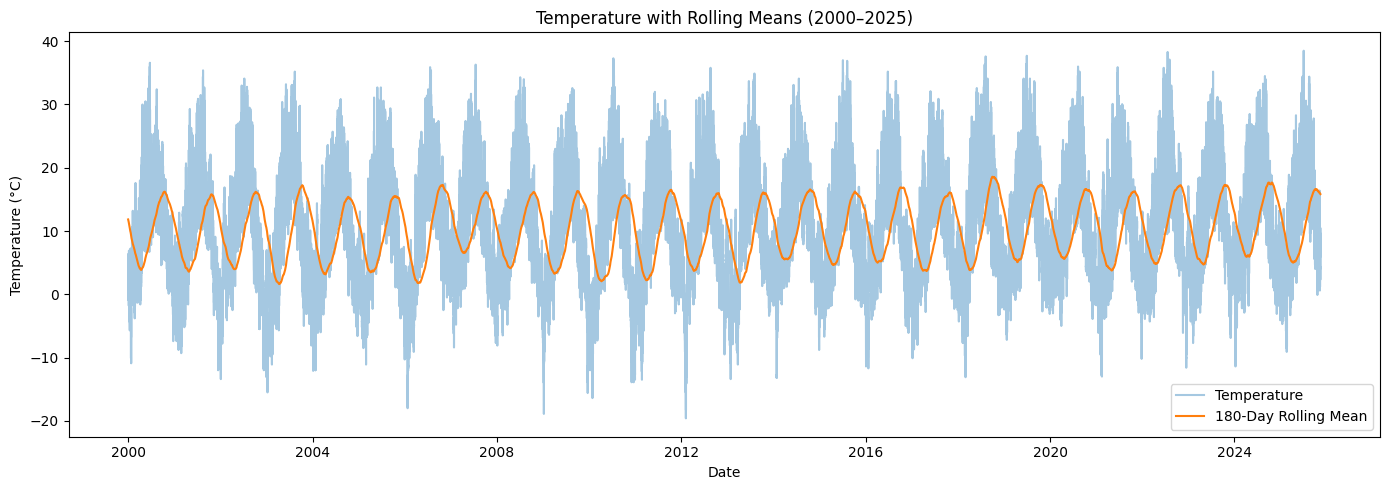

In [33]:
mask = (df.index >= "2000-01-01") & (df.index <= "2025-12-31")
df_filtered = df.loc[mask]
df_x = df.loc[mask]

plt.figure(figsize=(14,5))

plt.plot(df_x['temperature'], alpha=0.4, label='Temperature')
plt.plot(df_filtered['temp_roll_180d'], label='180-Day Rolling Mean')


plt.title("Temperature with Rolling Means (2000–2025)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
print(df.head())

                           temperature  temp_roll_7d  temp_roll_30d  \
date                                                                  
1893-01-01 01:00:00+00:00        -12.3           NaN            NaN   
1893-01-01 02:00:00+00:00        -10.9           NaN            NaN   
1893-01-01 03:00:00+00:00         -9.9           NaN            NaN   
1893-01-01 04:00:00+00:00         -9.4           NaN            NaN   
1893-01-01 05:00:00+00:00         -8.9           NaN            NaN   

                           temp_roll_365d  
date                                       
1893-01-01 01:00:00+00:00             NaN  
1893-01-01 02:00:00+00:00             NaN  
1893-01-01 03:00:00+00:00             NaN  
1893-01-01 04:00:00+00:00             NaN  
1893-01-01 05:00:00+00:00             NaN  


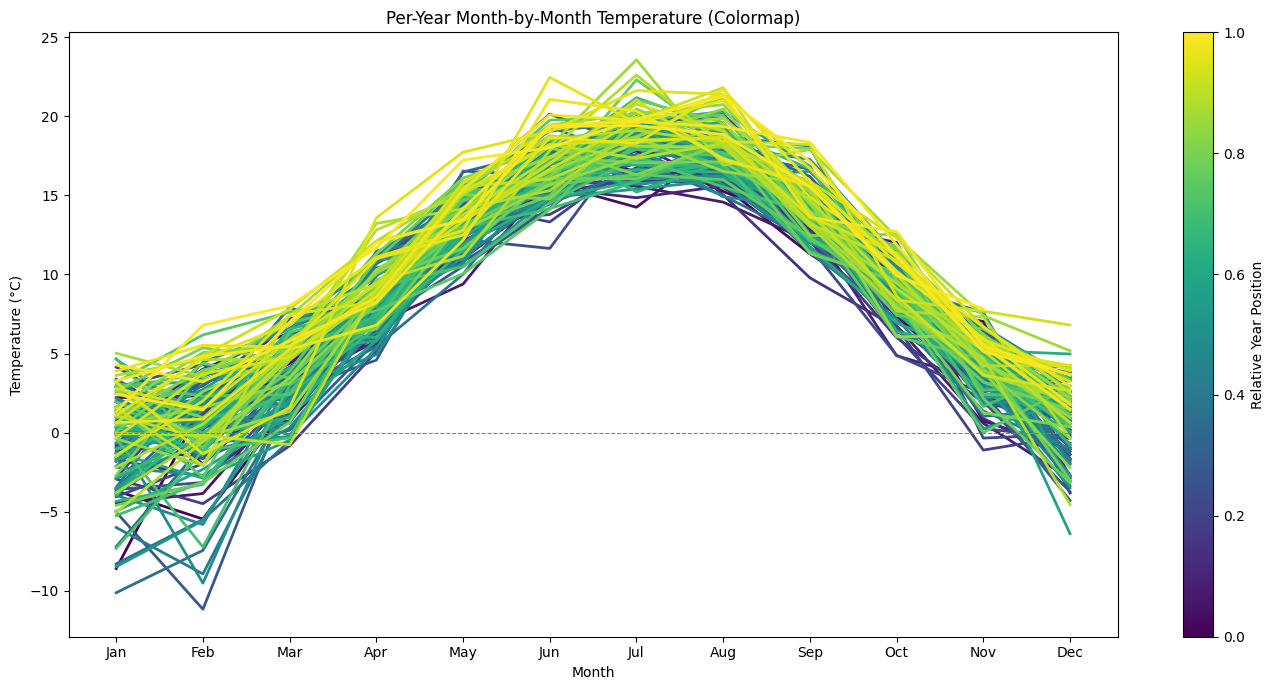

In [15]:
df['year'] = df.index.year
df['month'] = df.index.month
df['decade'] = (df['year'] // 10) * 10

monthly = df.groupby(['year','month'])['temperature'].mean().unstack()

plt.figure(figsize=(14,7))
ax = plt.gca() 

years = monthly.index
cmap = plt.cm.viridis
colors = cmap(np.linspace(0,1,len(years)))

for color, year in zip(colors, years):
    ax.plot(range(1,13), monthly.loc[year], color=color, linewidth=2)

ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Month")

ax.set_title("Per-Year Month-by-Month Temperature (Colormap)")

sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])


plt.colorbar(sm, ax=ax, label="Relative Year Position")
plt.hlines(0, xmin=1, xmax=12, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()


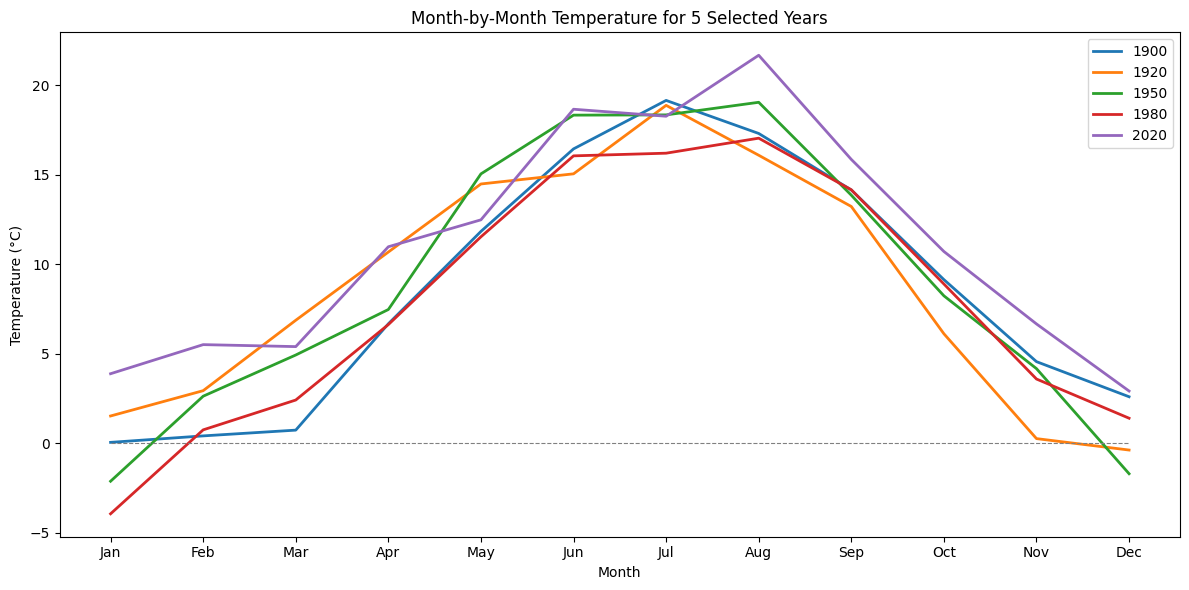

In [16]:
selected_years = [1900, 1920, 1950, 1980, 2020]  

subset = monthly.loc[monthly.index.isin(selected_years)]

plt.figure(figsize=(12,6))
for year in subset.index:
    plt.plot(range(1,13), subset.loc[year], label=str(year), linewidth=2)

plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.hlines(0, xmin=1, xmax=12, color='gray', linestyle='--', linewidth=0.8)
plt.title("Month-by-Month Temperature for 5 Selected Years")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
auc_results = {}

x = np.arange(1, 13)  # months 1–12

for year in selected_years:
    y = monthly.loc[year].values
    auc = np.trapezoid(y, x)
    auc_results[year] = auc

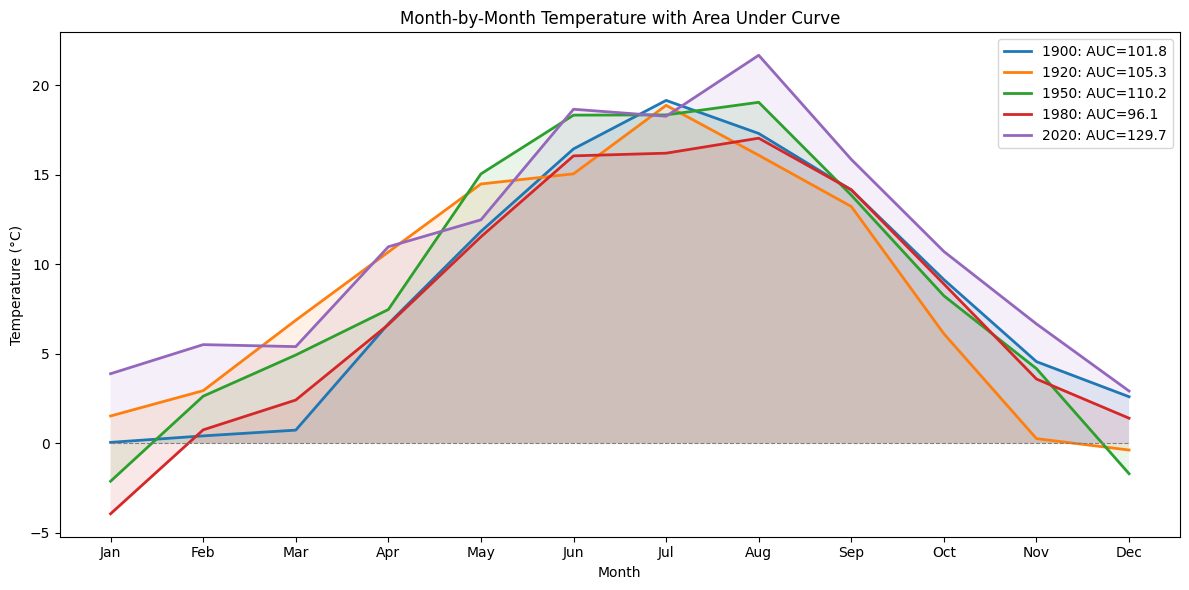

In [18]:
plt.figure(figsize=(12,6))
x = np.arange(1, 13)

for year in selected_years:
    y = monthly.loc[year].values
    plt.plot(x, y, linewidth=2, label=f"{year}: AUC={auc_results[year]:.1f}")
    plt.fill_between(x, y, alpha=0.1)   

plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Month-by-Month Temperature with Area Under Curve")
plt.legend()
plt.hlines(0, xmin=1, xmax=12, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

In [19]:
all_auc = {
    year: np.trapezoid(monthly.loc[year].values, x)
    for year in monthly.index
}

all_auc
auc_series = pd.Series(all_auc).sort_values(ascending=False)
auc_series.head(10)  

2024    138.656926
2019    132.828890
2018    130.388267
2014    129.836127
2020    129.712119
2022    129.616255
2023    129.462752
2015    123.060722
2000    122.830446
2016    122.395417
dtype: float64